# Day 1 - Session 3: Data Manipulation & Plotting

## Learning Objectives
- Read and write data from various file formats
- Understand and manipulate data frames
- Handle missing data
- Perform basic data cleaning operations
- Create visualizations with ggplot2
- Customize plot appearance
- Save publication-quality figures

## 1: Data Manipulation

### 1.1 Reading Data

There are several ways to import or access data in R:
- `R` already comes with several built-in datasets, which are frequently used for practice and examples. There are also several libraries that contain additional datasets
- Importing text files, using functions like `read.csv()`, `read.table()`
- Importing Excel files (using the `readxl` package or similars).

**Notes:** Although you can import from Excel, it is often better to convert Excel files to `.csv`, `.tsv` or `.txt` format first, as these are more universally compatible and easier to handle in R.

#### 1.1.1. Reading Built-in Datasets

In [10]:
# List available datasets
data()

# Load a specific dataset
data(iris)

?iris

Data sets in package 'datasets':

AirPassengers           Monthly Airline Passenger Numbers 1949-1960
BJsales                 Sales Data with Leading Indicator
BJsales.lead (BJsales)
                        Sales Data with Leading Indicator
BOD                     Biochemical Oxygen Demand
CO2                     Carbon Dioxide Uptake in Grass Plants
ChickWeight             Weight versus age of chicks on different diets
DNase                   Elisa assay of DNase
EuStockMarkets          Daily Closing Prices of Major European Stock
                        Indices, 1991-1998
Formaldehyde            Determination of Formaldehyde
HairEyeColor            Hair and Eye Color of Statistics Students
Harman23.cor            Harman Example 2.3
Harman74.cor            Harman Example 7.4
Indometh                Pharmacokinetics of Indomethacin
InsectSprays            Effectiveness of Insect Sprays
JohnsonJohnson          Quarterly Earnings per Johnson & Johnson Share
LakeHuron               Level 

iris                 package:datasets                  R Documentation

_E_d_g_a_r _A_n_d_e_r_s_o_n'_s _I_r_i_s _D_a_t_a

_D_e_s_c_r_i_p_t_i_o_n:

     This famous (Fisher's or Anderson's) iris data set gives the
     measurements in centimeters of the variables sepal length and
     width and petal length and width, respectively, for 50 flowers
     from each of 3 species of iris.  The species are _Iris setosa_,
     _versicolor_, and _virginica_.

_U_s_a_g_e:

     iris
     iris3
     
_F_o_r_m_a_t:

     'iris' is a data frame with 150 cases (rows) and 5 variables
     (columns) named 'Sepal.Length', 'Sepal.Width', 'Petal.Length',
     'Petal.Width', and 'Species'.

     'iris3' gives the same data arranged as a 3-dimensional array of
     size 50 by 4 by 3, as once provided by S-PLUS.  The first
     dimension gives the case number within the species subsample, the
     second the measurements with names 'Sepal L.', 'Sepal W.', 'Petal
  

You can use the lessons from the previous session to explore this new data-frame.

In [ ]:
# Explore the iris dataset
head(iris)
str(iris)
summary(iris)
dim(iris)

#### 1.1.2 Reading text files

`R` provides a set of functions that enables importing data in text files: `read.csv` and `read.table` are the two more common ones.

As an example, let's create and read a created CSV file:

In [9]:
# First, let's create a sample CSV file
# sample_data <- data.frame(
#   patient_id = 1:10,
#   age = c(25, 34, 45, 23, 67, 54, 32, 29, 41, 38),
#   treatment = rep(c("A", "B"), each=5),
#   response = c(7.2, 8.1, 6.5, 7.8, 5.4, 8.9, 9.2, 7.1, 6.8, 8.5)
# )

# # Write to CSV
# write.csv(sample_data, "../data/sample_data.csv", row.names=FALSE)

# Read CSV file
data <- read.csv("../data/sample_data.csv")
head(data)

,patient_id,age,treatment,response
,<int>,<int>,<chr>,<dbl>
1,1,25,A,7.2
2,2,34,A,8.1
3,3,45,A,6.5
4,4,23,A,7.8
5,5,67,A,5.4
6,6,54,B,8.9


### 1.2 Exploring Data Frames

For the following sections, we are going to use the built-in dataset `iris`. 

Let us start by exploring the data frame we just imported, using functions we previously learned:

In [11]:
# Basic exploration functions
head(iris)        # First 6 rows
tail(iris)        # Last 6 rows
str(iris)         # Data structure
summary(iris)     # Summary statistics
names(iris)       # Column names
dim(iris)         # Rows and columns

table(iris$Species)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
145,6.7,3.3,5.7,2.5,virginica
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica
150,5.9,3.0,5.1,1.8,virginica


'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

[1] "Sepal.Length" "Sepal.Width"  "Petal.Length" "Petal.Width"  "Species"

[1] 150   5


    setosa versicolor  virginica 
        50         50         50 

### 1.3 Subsetting Data Frames

As explored before, we can subset vectors & data-frames. Let us do this to our dataset:

In [ ]:
# Select single column (returns a vector)
iris$Sepal.Length

# Select multiple columns
iris[, c("Sepal.Length", "Sepal.Width")]

# Filter rows based on conditions
setosa <- iris[iris$Species == "setosa", ]
head(setosa)

# Multiple conditions
large_setosa <- iris[iris$Species == "setosa" & iris$Sepal.Length > 5, ]
head(large_setosa)

Additionally, for data-frames, you can also use the function `subset()`:

In [ ]:
# Using subset() function
setosa_sub <- subset(iris, Species == "setosa")
head(setosa_sub)

# Select specific columns while filtering
setosa_sepal <- subset(iris, 
                       Species == "setosa", 
                       select = c(Sepal.Length, Sepal.Width))
head(setosa_sepal)

### 1.4 Adding and Modifying Columns

You can treat the columns of a data-frame as vectors, and thus use mathematical operations on them; afterwards, you can save those results as new columns:

In [12]:
# Create a copy to modify
iris_modified <- iris

# Add new column
iris_modified$Sepal.Area <- iris_modified$Sepal.Length * iris_modified$Sepal.Width
head(iris_modified)

# Create categorical variable
iris_modified$Size <- ifelse(iris_modified$Petal.Length > 4, "Large", "Small")
table(iris_modified$Size)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,Sepal.Area
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,5.1,3.5,1.4,0.2,setosa,17.85
2,4.9,3.0,1.4,0.2,setosa,14.70
3,4.7,3.2,1.3,0.2,setosa,15.04
4,4.6,3.1,1.5,0.2,setosa,14.26
5,5.0,3.6,1.4,0.2,setosa,18.00
6,5.4,3.9,1.7,0.4,setosa,21.06



Large Small 
   84    66 

#### Additional Nugget - Checking & Filtering Missing Data 

You can have missing data in your data-frames (which, in `R`, is represented as `NA`). You can check for missing data using several functions:

In [ ]:
# Create data with missing values
data_na <- data.frame(
  id = 1:8,
  value1 = c(10, 20, NA, 40, 50, NA, 70, 80),
  value2 = c(5, NA, 15, 20, NA, 30, 35, 40)
)

# Check for NA values
is.na(data_na)          # Returns logical matrix
sum(is.na(data_na))     # Total number of NAs
colSums(is.na(data_na)) # NAs per column

Additionally, you can modify these entries or remove them entirely:

In [ ]:
# Remove rows with any NA
data_complete <- na.omit(data_na)
print(data_complete)

# Replace NA with a value
data_replaced <- data_na
data_replaced$value1[is.na(data_replaced$value1)] <- 0
print(data_replaced)

---

## Part 2: Data Visualization

`R` natively provides some functions for data visualization (e.g., `plot()`, `hist()`, etc.). However, the most widely used package for data visualization in `R` is `ggplot2`.

### 2.1 Native R Plotting Functions

Before we explore ggplot2, let's look at R's built-in plotting functions. These are powerful, quick to use, and don't require additional packages.

**Basic plotting functions:**
- **plot()**: Creates scatter plots and other basic plots
- **hist()**: Generates histograms
- **boxplot()**: Creates box-and-whisker plots

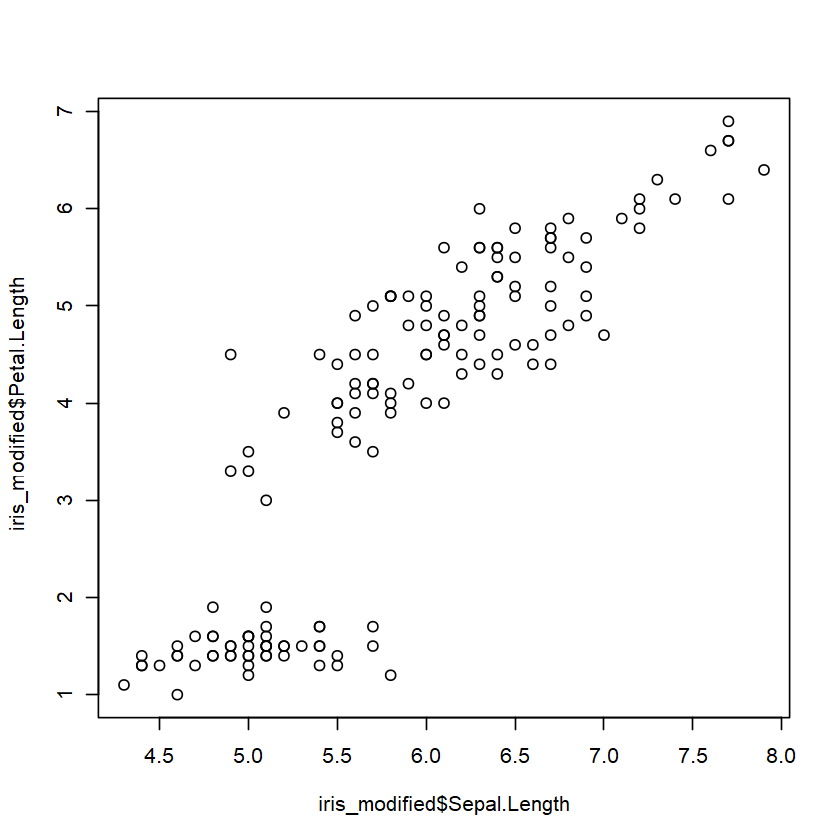

In [14]:
plot(iris_modified$Sepal.Length, iris_modified$Petal.Length)

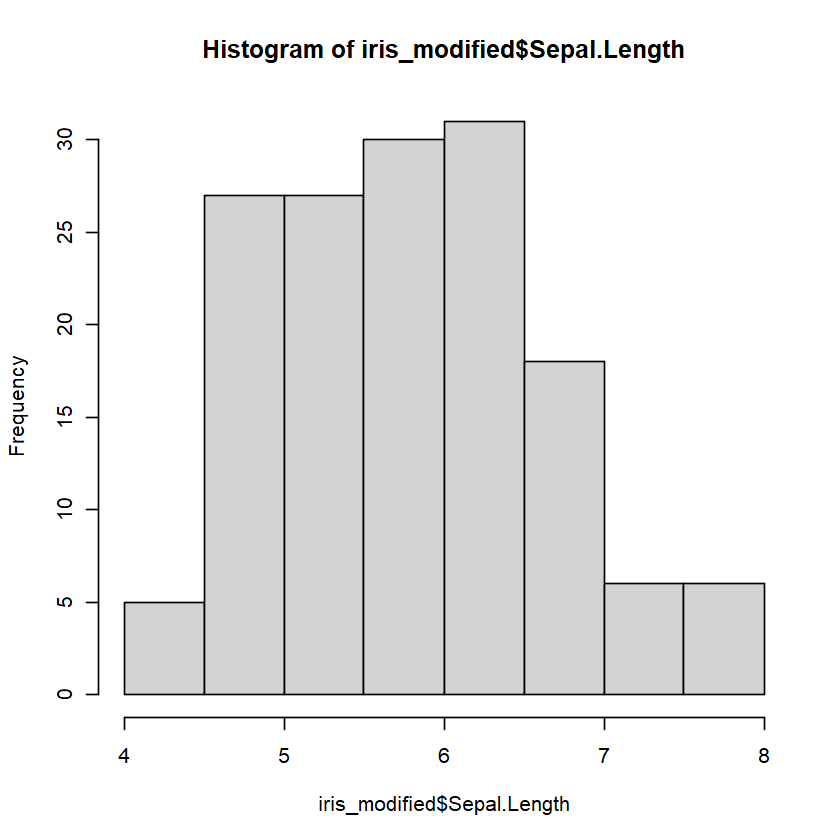

In [15]:
hist(iris_modified$Sepal.Length)

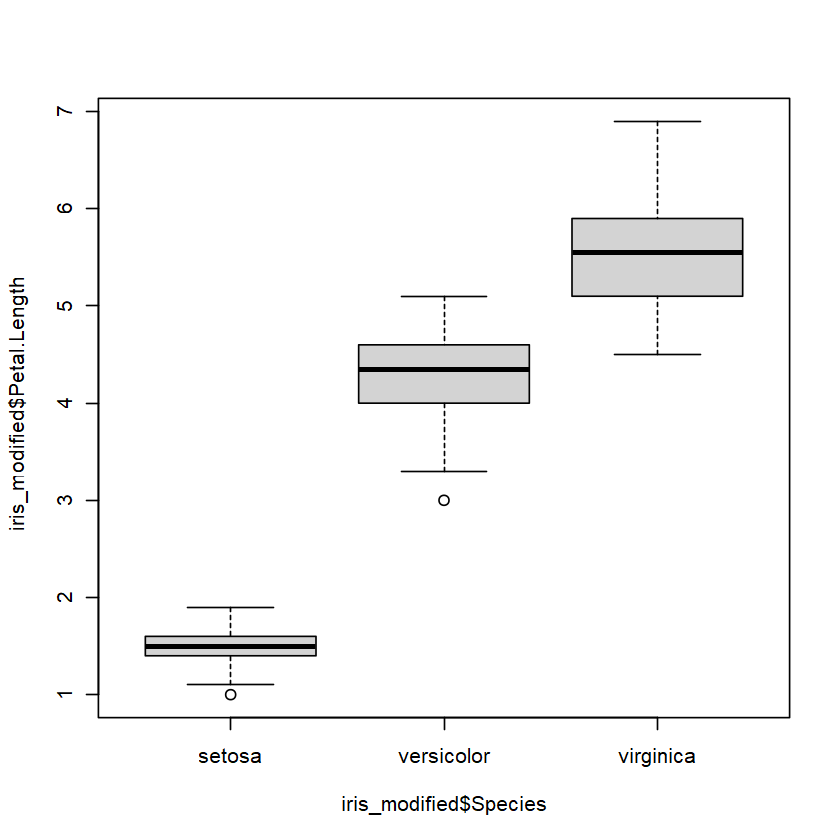

In [23]:
boxplot(iris_modified$Petal.Length ~ iris_modified$Species)

#plot(iris_modified$Species, iris_modified$Petal.Length)


You can customize these plots using two main approaches:
1. By adding parameters directly to the plotting function 
2. By using additional functions to modify the plot after its creation

This second approach follows a logic similar to Photoshop, in which each image has layers, which are modifiable independently. Do not forget this approach, since it will be relevant for `ggplot2` as well!

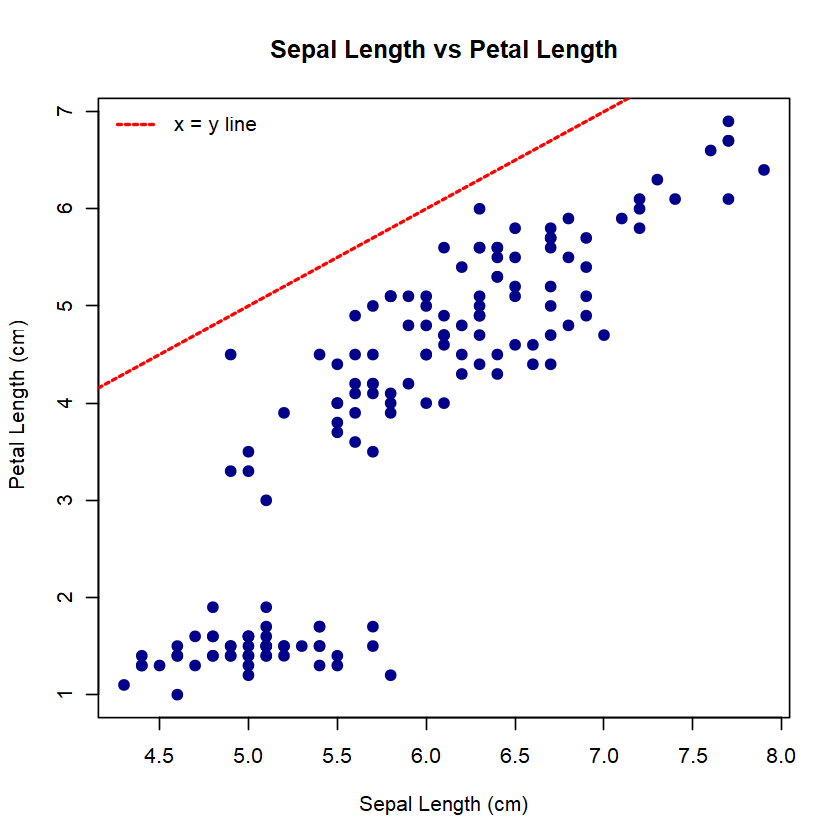

In [24]:
# Plot two continuous variables from iris_modified
# Using Sepal.Length vs Petal.Length
plot(iris_modified$Sepal.Length, iris_modified$Petal.Length,
     col = "darkblue",           # Change color to dark blue
     pch = 19,                    # Solid circle points
     xlab = "Sepal Length (cm)",  # X-axis label
     ylab = "Petal Length (cm)",  # Y-axis label
     main = "Sepal Length vs Petal Length")

# Add an x=y reference line (identity line)
abline(a = 0, b = 1, col = "red", lwd = 2, lty = 2)  # a=intercept, b=slope

# Add a legend
legend("topleft", legend = "x = y line", 
       col = "red", lty = 2, lwd = 2, bty = "n")

### 2.2. Introduction to `ggplot2`

**`ggplot2`** is one of the most used `R` packages, since it provides clean and often publication-ready plots. It is based on the "Grammar of Graphics" - a systematic way to build visualizations layer by layer.

For a `ggplot2` plot to be produced, it requires several layers: 
- **Base Layer**: This is where you define your dataset, and add aesthetic information (i.e., which variables go to which axes, colors, sizes, etc.) that become <u>the default in the plot</u>.
- **Geometric Layer(s)**: This is where you define the geometric objects that will represent your data (points, lines, bars, etc.). You can add multiple geometric layers to the same plot.
- **Labels**: This layer allows you to add titles, axis labels, and captions to your plot.
- **Theme**: This layer allows you to customize the overall appearance of your plot (background color, grid lines, font sizes, etc.).

In [26]:
# Load ggplot2
library(ggplot2)

Let us start with a simple example:

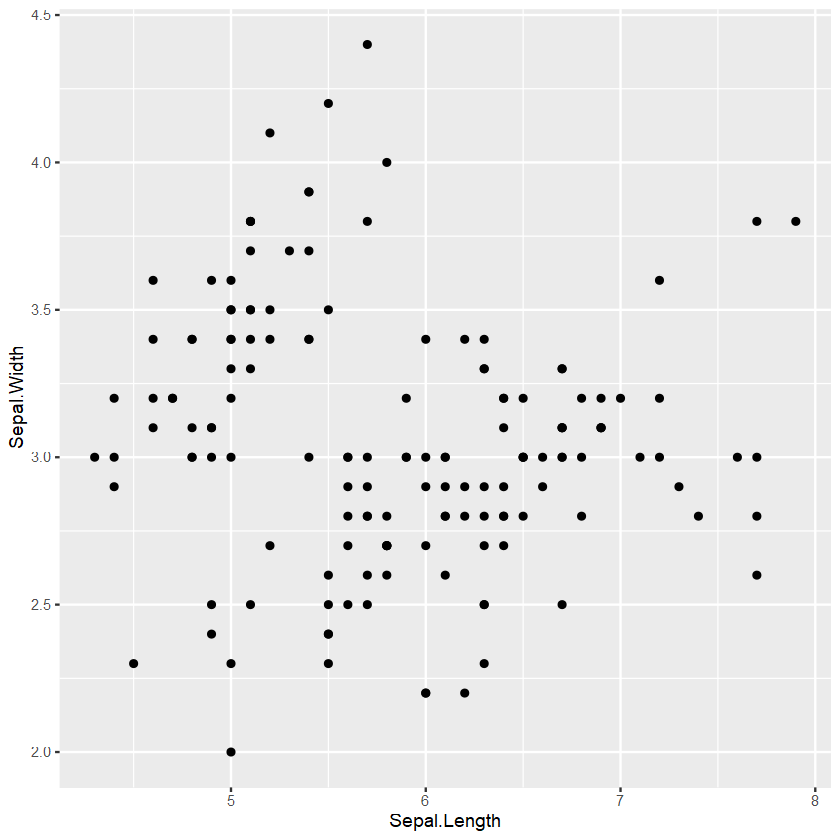

In [30]:
# Basic scatter plot
ggplot(iris_modified, aes(x = Sepal.Length, y = Sepal.Width)) + # Base Layer
  geom_point() # Geometric Layer

A more elaborate version of the same plot:

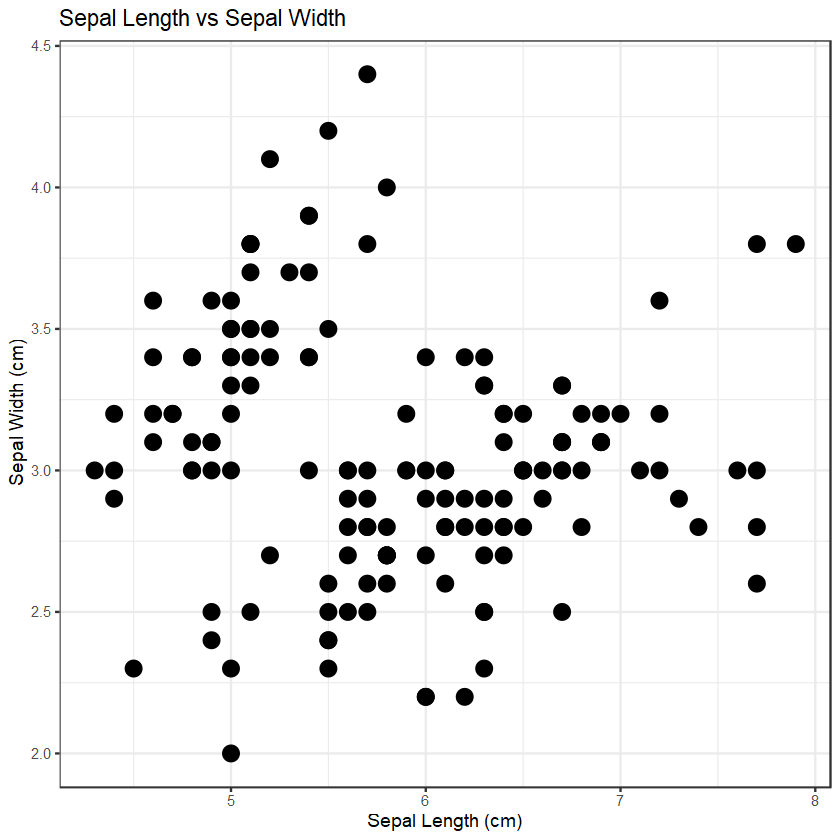

In [37]:
ggplot(iris_modified, aes(x = Sepal.Length, y = Sepal.Width)) + # Base Layer
  geom_point(size=4) + # Geometry Layer
  labs(title = "Sepal Length vs Sepal Width", x = "Sepal Length (cm)", y = "Sepal Width (cm)") + # Labels
  theme_bw() # Theme Layer

You can also add color or size aesthetics to your plots:

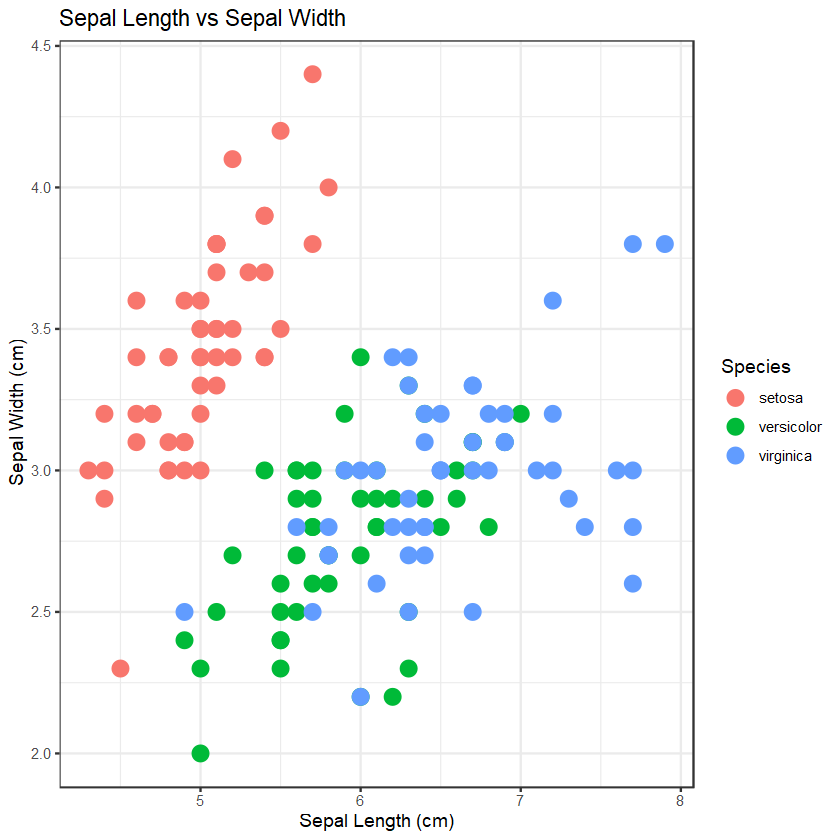

In [36]:
ggplot(iris_modified, aes(x = Sepal.Length, y = Sepal.Width)) + # Base Layer
  geom_point(aes(color=Species),size=4) + # Geometry Layer
  labs(title = "Sepal Length vs Sepal Width", x = "Sepal Length (cm)", y = "Sepal Width (cm)") + # Labels
  theme_bw() # Theme Layer

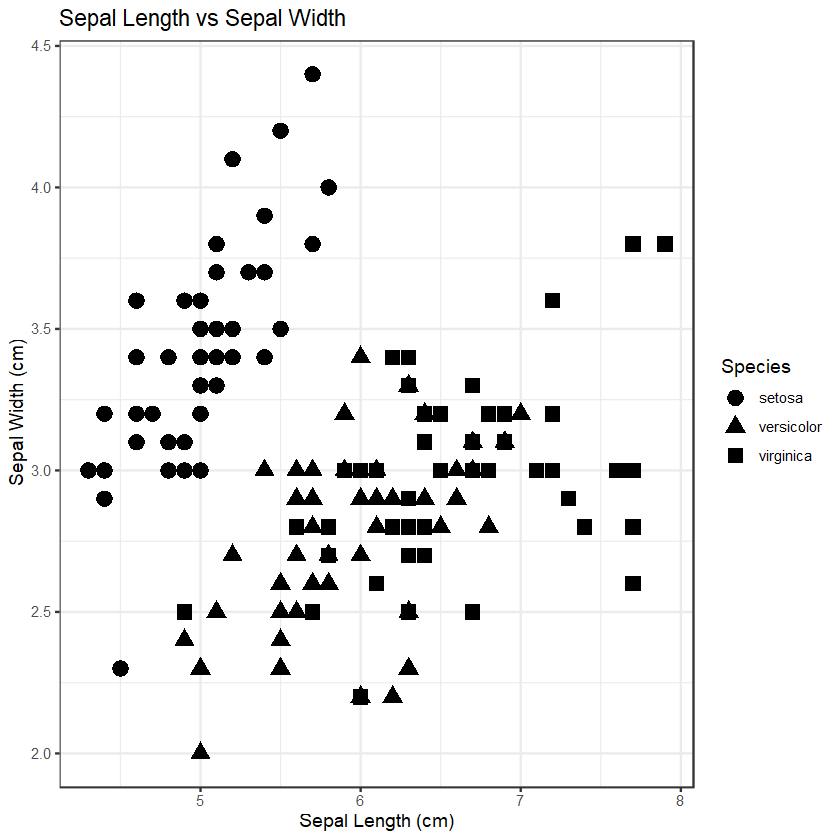

In [ ]:
ggplot(iris_modified, aes(x = Sepal.Length, y = Sepal.Width)) + # Base Layer
  geom_point(aes(shape=Species),size=4) + # Geometry Layer
  labs(title = "Sepal Length vs Sepal Width", x = "Sepal Length (cm)", y = "Sepal Width (cm)") + # Labels
  theme_bw() # Theme Layer

Warning message:
"Using size for a discrete variable is not advised."


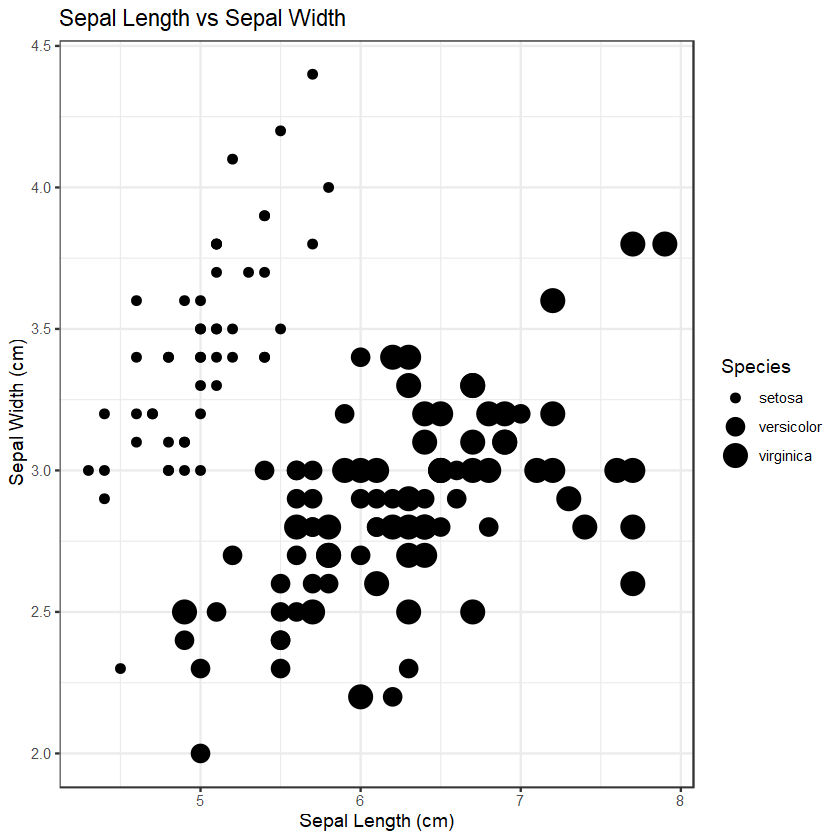

In [38]:
ggplot(iris_modified, aes(x = Sepal.Length, y = Sepal.Width)) + # Base Layer
  geom_point(aes(size=Species)) + # Geometry Layer
  labs(title = "Sepal Length vs Sepal Width", x = "Sepal Length (cm)", y = "Sepal Width (cm)") + # Labels
  theme_bw() # Theme Layer

There are additional plot types you can create with `ggplot2`, such as boxplots, and bar plots. The logic behind it is to <u> change the geometric layer </u>:

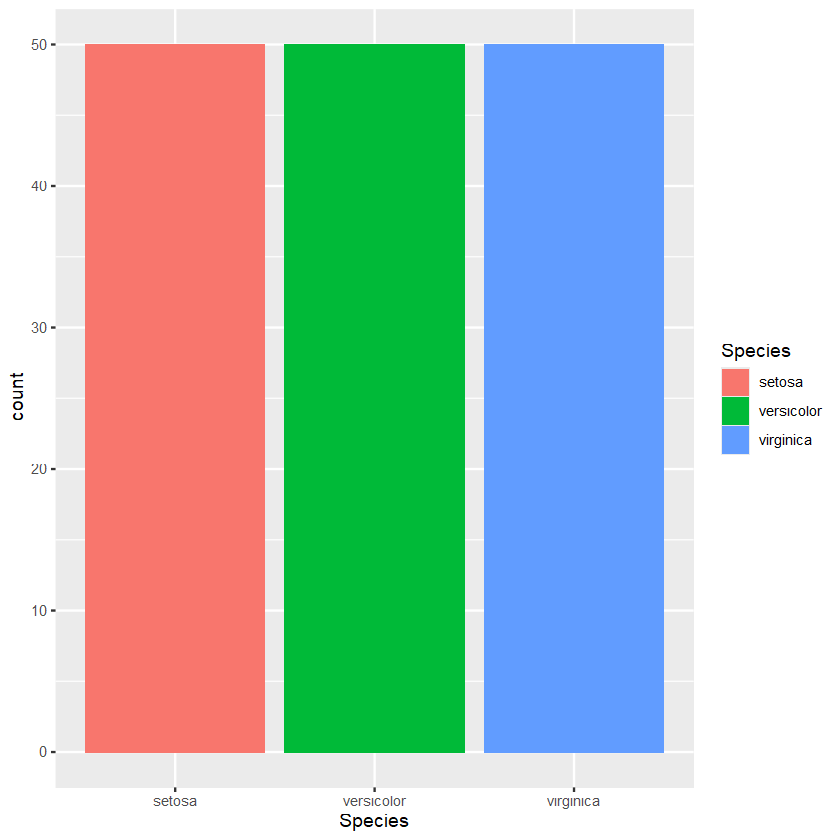

In [39]:
# Simple bar plot (count)
ggplot(iris_modified, aes(x = Species, fill = Species)) +
  geom_bar()

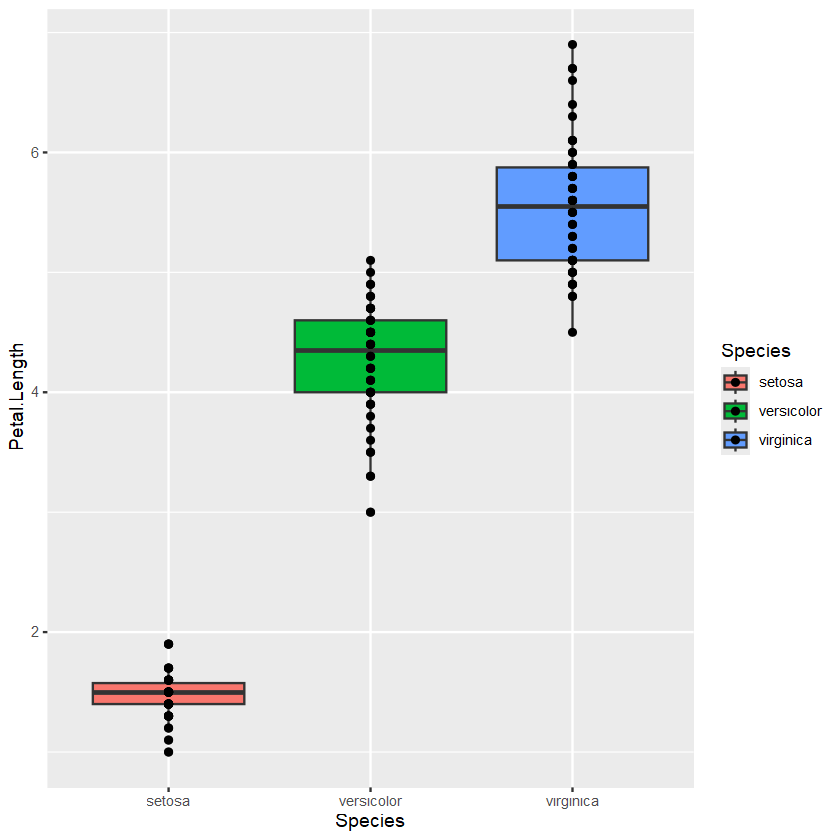

In [ ]:
# Basic boxplot
ggplot(iris_modified, aes(x = Species, y = Petal.Length, fill = Species)) +
  geom_boxplot()

An additional layer that can be added (optionally) is the facetting layer, which allows you to create multiple sub-plots based on the values of a categorical variable:

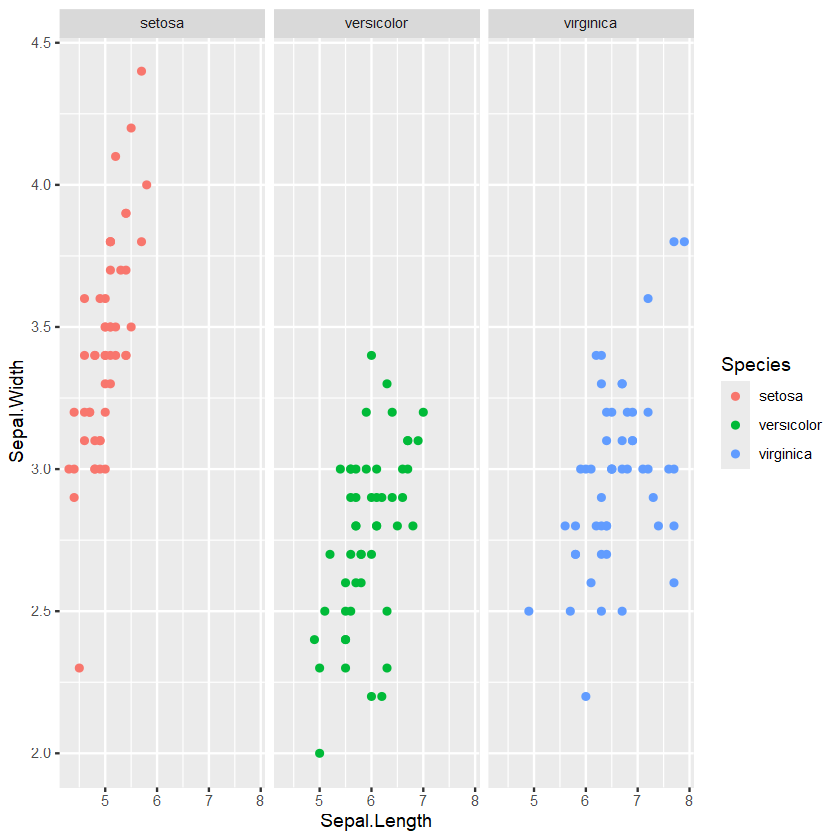

In [42]:
# Facet by one variable
ggplot(iris_modified, aes(x = Sepal.Length, y = Sepal.Width)) +
  geom_point(aes(color = Species)) +
  facet_wrap(~ Species)

Finally, you can save your plots using the `ggsave()` function:

In [ ]:
# Save as PNG
ggsave("iris_plot.png", plot = my_plot, width = 8, height = 6, dpi = 300)

# Save as PDF (vector format - best for publications)
ggsave("iris_plot.pdf", plot = my_plot, width = 8, height = 6)

print("Plots saved!")

---

## Practice Exercises

### Exercise 1: Data Manipulation
Using the iris dataset:
1. Filter for virginica species with Petal.Length > 6
2. Select only the Petal.Length and Petal.Width columns
3. Check several descriptive statictics for these columns

In [ ]:
# Your code here

### Exercise 2: Data Visualization

1. Create a scatter plot of Sepal Length vs Sepal Area using the native `R` functions and `ggplot2`
2. Create a boxplot of Sepal Area by Species using `ggplot2`, with the original points overlaid
3. Now, change the plotting theme of your boxplot (hint: we have already used themes before!) 

In [ ]:
# Your code here

## Session Info

It's good practice to record your R session information at the end of your analysis. This helps with reproducibility by documenting:
- R version
- Operating system
- Loaded packages and their versions
- Other system details

In [ ]:
sessionInfo()